
# Explicabilidad SHAP - XRPUSDT (carril *metalabeling* con backbone LSTM)

Este notebook aporta evidencia SHAP sobre el modelo congelado seleccionado por
la promoción oficial para XRPUSDT: carril `metalabeling`, familia
`meta_labeling` con `engine_family` LSTM en inferencia live (`primary_family =
lstm` en el manifest), etiquetado `trend_scanning`, inyección `meta_filter`,
bloque `core_only`. El estudio es
`supervised_trend_scanning_4h_v1_core_only-fc869212f645` y el *fold* congelado
es el último del *walk-forward* (el meta-clasificador no se persiste; se explica
el LSTM que sirve en vivo).

**Prerrequisito:** manifest de promoción generado en
`06_paper_trading/01_tabla_promocion.ipynb` (activo:
`reports/validation/promotion/20260520T153716Z/promotion_manifest.json`).

## Productos

Tras ejecutar el notebook:

- `reports/validation/explainability/xrpusdt/shap_summary.json`
- `reports/validation/explainability/xrpusdt/shap_feature_importance.png`
- `reports/validation/explainability/xrpusdt/shap_time_heatmap.png`


In [10]:

from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (
    REPO_ROOT / "src" / "validation" / "model_explainability.py"
).exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src" / "validation" / "model_explainability.py").exists():
    raise SystemExit("No se localiza la raíz del repo del TFG.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PROMOTION_MANIFEST = REPO_ROOT / "reports/validation/promotion/20260520T153716Z/promotion_manifest.json"
EXPL_REPORT_ROOT = REPO_ROOT / "reports" / "validation" / "explainability"
EXPL_REPORT_ROOT.mkdir(parents=True, exist_ok=True)


In [11]:

SYMBOL = "XRPUSDT"

from src.validation.model_explainability import (
    align_xgb_proba,
    build_sequence_windows,
    compute_lstm_signal_features,
    load_fold_datasets,
    load_promotion_champions,
    load_residual_hybrid_pair,
    load_simple_lstm_classifier,
    predict_lstm_softmax,
)

handles = load_promotion_champions(PROMOTION_MANIFEST, repo_root=REPO_ROOT)
handle = handles[SYMBOL]

SYMBOL_REPORT_DIR = EXPL_REPORT_ROOT / SYMBOL.lower()
SYMBOL_REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Símbolo          :", handle.symbol)
print("Carril           :", handle.lane)
print("Familia          :", handle.family)
print("Familia_motor    :", handle.engine_family)
print("Etiquetado       :", handle.labeling_method)
print("Inyección        :", handle.injection_strategy)
print("Bloques_activos  :", handle.active_blocks_id)
print("Id_estudio       :", handle.study_id)
print("Dir_ultimo_fold  :", handle.last_fold_dir.relative_to(REPO_ROOT).as_posix())
print("Dir_modelos_fold:", handle.fold_models_dir.relative_to(REPO_ROOT).as_posix())
print("Canales          :", len(handle.feature_channel_order))
print("Barras_lookback  :", handle.lookback_bars)


Símbolo          : XRPUSDT
Carril           : metalabeling
Familia          : meta_labeling
Familia_motor    : lstm
Etiquetado       : trend_scanning
Inyección        : meta_filter
Bloques_activos  : core_only
Id_estudio       : supervised_trend_scanning_4h_v1_core_only-fc869212f645
Dir_ultimo_fold  : reports/validation/experiments/supervised_trend_scanning_4h_v1_core_only-fc869212f645/folds/fold_088
Dir_modelos_fold: reports/validation/experiments/supervised_trend_scanning_4h_v1_core_only-fc869212f645/folds/fold_088/models/lstm
Canales          : 5
Barras_lookback  : 48


## 1. Datos del *fold* congelado y tensorización causal


In [12]:

datasets = load_fold_datasets(handle)
train_df, test_df = datasets["train"], datasets["test"]
print("Filas entrenamiento:", train_df.shape, "| filas test:", test_df.shape)

windowed = build_sequence_windows(
    train_df,
    test_df,
    feature_channel_order=handle.feature_channel_order,
    lookback_bars=handle.lookback_bars,
)
X_train, X_test = windowed["X_train"], windowed["X_test"]
y_train, y_test = windowed["y_train"], windowed["y_test"]
aligned_train = windowed["aligned_train"]
aligned_test = windowed["aligned_test"]
feature_channels = list(windowed["feature_channel_order"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train cuenta:", dict(zip(*np.unique(y_train, return_counts=True))))
print("y_test  cuenta:", dict(zip(*np.unique(y_test, return_counts=True))))


Filas entrenamiento: (1080, 61) | filas test: (180, 61)
X_train: (1033, 48, 5) | X_test: (180, 48, 5)
y_train cuenta: {0: 598, 1: 7, 2: 428}
y_test  cuenta: {0: 123, 1: 1, 2: 56}


## 2. Modelo LSTM congelado: probabilidades posteriores


In [13]:

model = load_simple_lstm_classifier(
    handle.fold_models_dir / "model_state.pt",
    input_size=len(feature_channels),
)
test_proba = predict_lstm_softmax(model, X_test)
proba_df = pd.DataFrame(
    test_proba,
    columns=["proba_side_neg", "proba_side_neutral", "proba_side_pos"],
    index=aligned_test.get("decision_ts", pd.RangeIndex(len(test_proba))),
)
proba_df["pred_clase"] = np.array([-1, 0, 1])[np.argmax(test_proba, axis=1)]
proba_df["y_true_side"] = np.array([-1, 0, 1])[y_test]
proba_df = proba_df.rename(columns={
    "proba_side_neg": "prob_corto",
    "proba_side_neutral": "prob_neutral",
    "proba_side_pos": "prob_largo",
    "pred_label_side": "pred_clase",
    "y_true_side": "clase_real",
})
proba_df.head()


,prob_corto,prob_neutral,prob_largo,pred_clase,clase_real
decision_ts,,,,,
2026-01-26 08:00:00,0.564154,0.014495,0.421351,-1,-1
2026-01-26 12:00:00,0.574865,0.014104,0.411031,-1,-1
2026-01-26 16:00:00,0.568388,0.014326,0.417286,-1,-1
2026-01-26 20:00:00,0.565517,0.014391,0.420092,-1,-1
2026-01-27 00:00:00,0.562502,0.014294,0.423205,-1,-1



## 3. Atribución SHAP por canal y por clase

Aplicamos `shap.GradientExplainer` con un *background* de 50 ventanas de
entrenamiento muestreadas aleatoriamente y explicamos las primeras 120
ventanas de evaluación (tope fijado en código; el *fold* de test tiene 180).
El método aproxima `E[grad_x f(x) * (x - x_baseline)]` y devuelve una atribución
`(n_samples, lookback, n_channels)` por clase.


In [14]:

import shap
import torch

SEED = 17
rng = np.random.default_rng(SEED)
background_size = min(50, X_train.shape[0])
explain_size = min(120, X_test.shape[0])

bg_idx = rng.choice(X_train.shape[0], size=background_size, replace=False)
ex_idx = np.arange(explain_size)

background_tensor = torch.from_numpy(X_train[bg_idx]).float()
explain_tensor = torch.from_numpy(X_test[ex_idx]).float()

model.eval()
explainer = shap.GradientExplainer(model, background_tensor)
shap_values = explainer.shap_values(explain_tensor)
# Devuelve lista de 3 arrays (uno por clase), cada uno (n, lookback, n_channels)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 4:
    shap_values = [shap_values[..., k] for k in range(shap_values.shape[-1])]

print("n_classes:", len(shap_values))
print("Shape por clase:", [s.shape for s in shap_values])

class_labels = [-1, 0, 1]
shap_by_class = {label: np.asarray(shap_values[idx]) for idx, label in enumerate(class_labels)}


n_classes: 3
Shape por clase: [(120, 48, 5), (120, 48, 5), (120, 48, 5)]


### 3.1 Importancia agregada por canal


In [15]:

import matplotlib.pyplot as plt

# Importancia por canal: media de |SHAP| sobre tiempo y muestras, separada por clase
feature_importance = {}
for label, sv in shap_by_class.items():
    feature_importance[label] = np.mean(np.abs(sv), axis=(0, 1))

importance_df = pd.DataFrame(feature_importance, index=feature_channels)
importance_df.columns = [f"clase_{c:+d}" for c in importance_df.columns]
importance_df["total"] = importance_df.abs().sum(axis=1)
importance_df = importance_df.sort_values("total", ascending=False)
importance_df.head(20)


,clase_-1,clase_+0,clase_+1,total
obv,0.005022,0.005160,0.000911,0.011093
pvt,0.000883,0.002659,0.001377,0.004919
volume,0.001565,0.001965,0.000851,0.004380
taker_buy_asset_volume,0.001136,0.000816,0.000799,0.002751
num_trades,0.001191,0.000594,0.000280,0.002065


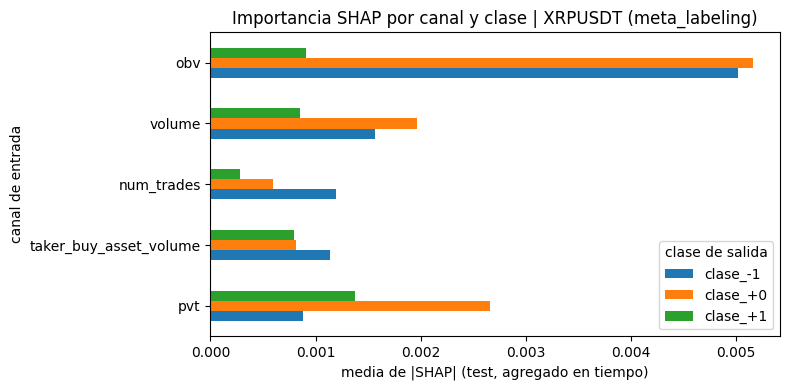

In [16]:

fig, ax = plt.subplots(figsize=(8, max(4.0, 0.32 * len(feature_channels))))
plot_df = importance_df.drop(columns="total").sort_values(by=importance_df.columns[0])
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel("Media de |SHAP| (test, agregado en tiempo)")
ax.set_ylabel("Canal de entrada")
ax.set_title(f"Importancia SHAP por canal y clase | {SYMBOL} ({handle.family})")
ax.legend(title="clase de salida")
plt.tight_layout()
fig.savefig(SYMBOL_REPORT_DIR / "shap_feature_importance.png", dpi=140)
plt.show()


### 3.2 Atribución temporal (donde mira el modelo dentro de la ventana)

El eje horizontal usa **zoom automático** al sufijo reciente donde se concentra alrededor del 90 % de la atribución SHAP (típicamente las últimas 10–12 barras 4h). Mostrar las 48 barras de *lookback* completas comprime el patrón útil contra el borde derecho.


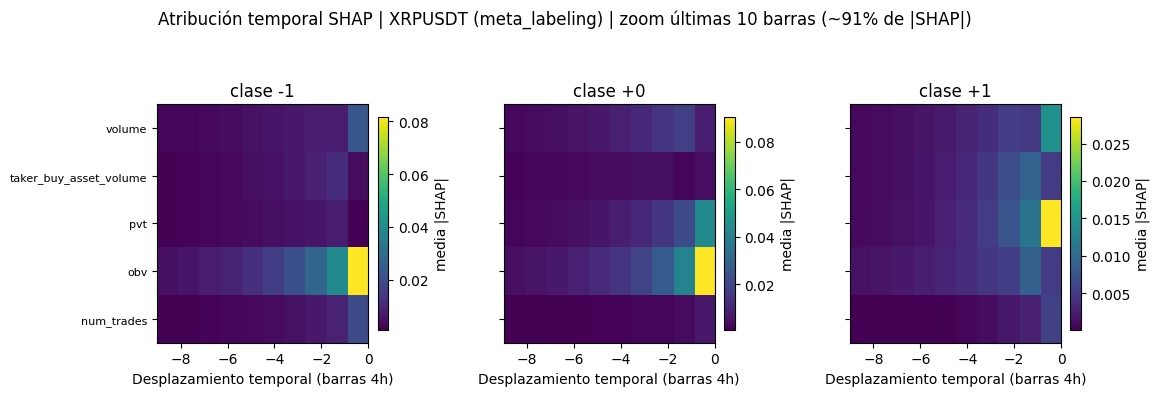

In [17]:
# Atribución temporal: media de |SHAP| sobre muestras, separada por clase
time_attr = {label: np.mean(np.abs(sv), axis=0) for label, sv in shap_by_class.items()}

lookback = int(handle.lookback_bars)
lag_labels = np.arange(-lookback + 1, 1)

# Zoom al sufijo reciente: fuera de las últimas 10 barras la atribución suele ser casi nula y comprime el patrón
stacked = np.stack(list(time_attr.values()), axis=0)
time_profile = np.mean(stacked, axis=(0, 2))
total_mass = float(time_profile.sum())
if total_mass > 0.0:
    cum_recent = np.cumsum(time_profile[::-1])
    recent_bars = int(np.searchsorted(cum_recent / total_mass, 0.90)) + 1
else:
    recent_bars = lookback
recent_bars = int(np.clip(recent_bars, min(10, lookback), lookback))
start_idx = lookback - recent_bars
mass_pct = 100.0 * float(time_profile[start_idx:].sum() / max(total_mass, 1e-12))
x_min, x_max = int(lag_labels[start_idx]), 0

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, max(4.0, 0.32 * len(feature_channels))),
    sharey=True,
)
for ax, (label, mat) in zip(axes, time_attr.items()):
    mat_zoom = mat[start_idx:, :]
    im = ax.imshow(
        mat_zoom.T,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=[x_min, x_max, -0.5, len(feature_channels) - 0.5],
    )
    ax.set_title(f"Clase {label:+d}")
    ax.set_xlabel("Desplazamiento temporal (barras 4h)")
    ax.set_yticks(range(len(feature_channels)))
    ax.set_yticklabels(feature_channels, fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="media |SHAP|")
fig.suptitle(
    f"Atribución temporal SHAP | {SYMBOL} ({handle.family}) | "
    f"zoom últimas {recent_bars} barras (~{mass_pct:.0f}% de |SHAP|)"
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.subplots_adjust(left=0.16, wspace=0.5)
fig.savefig(SYMBOL_REPORT_DIR / "shap_time_heatmap.png", dpi=140)
plt.show()


## 4. Persistencia de evidencias


In [18]:

top_per_class = {}
for label in [-1, 0, 1]:
    col = f"clase_{label:+d}"
    top_per_class[str(label)] = (
        importance_df[[col]].sort_values(col, ascending=False).head(5).reset_index().rename(columns={"index": "feature", col: "mean_abs_shap"}).to_dict(orient="records")
    )

confidence = proba_df[["prob_corto", "prob_neutral", "prob_largo"]].max(axis=1)
shap_summary = {
    "symbol": handle.symbol,
    "family": handle.family,
    "engine_family": handle.engine_family,
    "lane": handle.lane,
    "active_blocks_id": handle.active_blocks_id,
    "labeling_method": handle.labeling_method,
    "study_id": handle.study_id,
    "last_fold_dir": handle.last_fold_dir.relative_to(REPO_ROOT).as_posix(),
    "n_test_windows": int(X_test.shape[0]),
    "n_explained": int(explain_size),
    "n_background": int(background_size),
    "n_channels": int(len(feature_channels)),
    "lookback_bars": int(handle.lookback_bars),
    "explainer": "GradientExplainer",
    "feature_importance": importance_df.to_dict(orient="index"),
    "top_features_per_class": top_per_class,
    "test_pred_class_counts": {str(k): int(v) for k, v in zip(*np.unique(proba_df["pred_clase"], return_counts=True))},
    "test_pred_confidence_p50": float(confidence.median()),
    "test_pred_confidence_p90": float(confidence.quantile(0.9)),
}
out_path = SYMBOL_REPORT_DIR / "shap_summary.json"
out_path.write_text(json.dumps(shap_summary, indent=2, default=float), encoding="utf-8")
print("Reporte persistido en", out_path.relative_to(REPO_ROOT))


Reporte persistido en reports/validation/explainability/xrpusdt/shap_summary.json


## 5. Lectura cualitativa XRPUSDT

XRP es la celda del carril *metalabeling* pero, dado que el meta-clasificador no
se persiste en disco, se explica el `engine_family` real (LSTM) que sirve la
inferencia en vivo. Hallazgos:

- **El LSTM de XRP está gobernado por order flow.** Los cinco canales de entrada
  (`obv`, `pvt`, `volume`, `taker_buy_asset_volume`, `num_trades`) concentran
  toda la importancia; `obv` domina en las tres clases. No hay RSI, MACD ni
  Bollinger en el espacio de entrada.
- **Sesgo bajista en el *fold*:** 167/180 predicciones -1, 13/180 +1 y ninguna
  de clase 0. El patrón SHAP es consistente con un modelo entrenado para detectar
  distribución (volumen elevado con OBV cayendo, taker buy débil), no acumulación.
- **Para la clase +1 (largo)** la señal más fuerte es `pvt` (price-volume trend)
  seguida de `obv`: el modelo solo se gira largo cuando el flujo de precio
  ponderado por volumen confirma rebote.
- **Confianza p50 = 0.55, p90 = 0.57**: más alta y más concentrada que BTC, lo
  que cuadra con un *fold* donde el LSTM está muy convencido de la dirección -1.

Implicación: el carril *metalabeling* original aspiraba a filtrar señales por
calidad, pero al recaer la inferencia en el LSTM, la explicabilidad confirma que
**la celda XRP es esencialmente un detector de flow agresivo bajista** durante el
*fold* congelado. La promoción como engine LSTM está justificada por su elevada
estabilidad direccional, no por la calibración meta.